# Intra-subject classification

This notebook trains three deep models on **windowed intra-subject MEG data** and evaluates them at **window level** (no majority vote):
- 1D Feature CNN (primary model)
- GAT
- CNN-GAT

All models follow one protocol: stratified 80/20 train/validation split from training windows, then final evaluation on `X_intra_test_w`.

In [1]:

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, sosfiltfilt, welch
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

CLASSES = ["rest", "motor", "math", "memory"]
DATA_DIR = "Preprocessed data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device: {DEVICE}")


PyTorch device: cpu


In [2]:

def load_dataset(name, base_dir=DATA_DIR):
    return np.load(os.path.join(base_dir, f"{name}.npy"))


def make_window_groups(n_windows, n_recordings):
    wpr = n_windows // n_recordings
    groups = np.repeat(np.arange(n_recordings), wpr)
    if len(groups) < n_windows:
        groups = np.concatenate([groups, np.arange(n_windows - len(groups)) + n_recordings])
    return groups[:n_windows]


def grouped_split_indices(y, groups, test_size=0.2, seed=42):
    # Prefer stratified + grouped split to avoid class skew in val while preventing group leakage.
    try:
        n_splits = max(3, min(8, int(round(1.0 / max(test_size, 1e-6)))))
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        tr, va = next(sgkf.split(np.zeros(len(y)), y, groups))
        return tr, va
    except Exception:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr, va = next(gss.split(np.zeros(len(y)), y, groups))
        return tr, va

X_intra_train_w = load_dataset("X_intra_train_w")
X_intra_test_w = load_dataset("X_intra_test_w")
y_intra_train_w = load_dataset("y_intra_train_w")
y_intra_test_w = load_dataset("y_intra_test_w")

# recording-level labels to define leakage-safe groups
y_intra_train_rec = load_dataset("y_intra_train")
train_groups = make_window_groups(len(y_intra_train_w), len(y_intra_train_rec))

print("X_intra_train_w:", X_intra_train_w.shape)
print("X_intra_test_w: ", X_intra_test_w.shape)
print("y_intra_train_w:", y_intra_train_w.shape)
print("y_intra_test_w: ", y_intra_test_w.shape)
print("train_groups:", train_groups.shape, "unique recordings:", len(np.unique(train_groups)))


X_intra_train_w: (512, 248, 500)
X_intra_test_w:  (64, 248, 500)
y_intra_train_w: (512,)
y_intra_test_w:  (64,)
train_groups: (512,) unique recordings: 32


## Primary model: 1D Feature CNN (TensorFlow/Keras)

Rationale: temporal 1D convolutions model oscillatory dynamics in each window, while appended bandpower features add compact spectral information.

In [3]:
def temporal_attention_1d(x):
    weights = layers.Dense(1, activation="tanh")(x)
    weights = layers.Softmax(axis=1)(weights)
    return layers.multiply([x, weights])


def squeeze_excite_1d(x, ratio=8):
    filters = int(x.shape[-1])
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(1, filters // ratio), activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, filters))(se)
    return layers.multiply([x, se])


def build_1d_cnn(input_shape, num_classes, dropout_rate=0.3, initial_filters=16, attention=False):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv1D(initial_filters, kernel_size=7, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 2, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.Conv1D(initial_filters * 4, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)
    if attention:
        x = temporal_attention_1d(x)
        x = squeeze_excite_1d(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="brain_state_1dcnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50),
}


def extract_band_power(X_data, fs=254.0, bands=BANDS):
    n_samples, n_sensors, _ = X_data.shape
    n_bands = len(bands)
    band_power = np.zeros((n_samples, n_sensors, n_bands), dtype="float32")

    for band_idx, (_, (f_low, f_high)) in enumerate(bands.items()):
        sos = butter(4, [f_low, f_high], btype="band", fs=fs, output="sos")
        for sample_idx in range(n_samples):
            for sensor_idx in range(n_sensors):
                filtered = sosfiltfilt(sos, X_data[sample_idx, sensor_idx])
                band_power[sample_idx, sensor_idx, band_idx] = np.var(filtered)

    return band_power


def expand_bandpower_for_1d(band_power, time_steps):
    expanded = np.repeat(band_power[:, np.newaxis, :, :], repeats=time_steps, axis=1)
    return expanded.reshape(band_power.shape[0], time_steps, -1)


def prepare_1d_feature_input(X):
    X_1d = np.transpose(X, (0, 2, 1)).astype("float32")
    bp = extract_band_power(X)
    X_1d_combined = np.concatenate([X_1d, expand_bandpower_for_1d(bp, X_1d.shape[1])], axis=-1)
    return X_1d_combined.astype("float32")

Epoch 1/40
26/26 - 2s - 78ms/step - accuracy: 0.4712 - loss: 1.3039 - val_accuracy: 0.3646 - val_loss: 1.3496 - learning_rate: 0.0010
Epoch 2/40
26/26 - 1s - 22ms/step - accuracy: 0.6923 - loss: 0.7418 - val_accuracy: 0.5521 - val_loss: 1.1712 - learning_rate: 0.0010
Epoch 3/40
26/26 - 1s - 22ms/step - accuracy: 0.8389 - loss: 0.4387 - val_accuracy: 0.6250 - val_loss: 0.9768 - learning_rate: 0.0010
Epoch 4/40
26/26 - 1s - 22ms/step - accuracy: 0.8942 - loss: 0.2926 - val_accuracy: 0.6250 - val_loss: 1.0096 - learning_rate: 0.0010
Epoch 5/40
26/26 - 1s - 22ms/step - accuracy: 0.9447 - loss: 0.1815 - val_accuracy: 0.7708 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 6/40
26/26 - 1s - 22ms/step - accuracy: 0.9615 - loss: 0.1437 - val_accuracy: 0.6771 - val_loss: 0.9164 - learning_rate: 0.0010
Epoch 7/40
26/26 - 1s - 22ms/step - accuracy: 0.9591 - loss: 0.1404 - val_accuracy: 0.6458 - val_loss: 0.9389 - learning_rate: 0.0010
Epoch 8/40
26/26 - 1s - 22ms/step - accuracy: 0.9712 - loss: 0

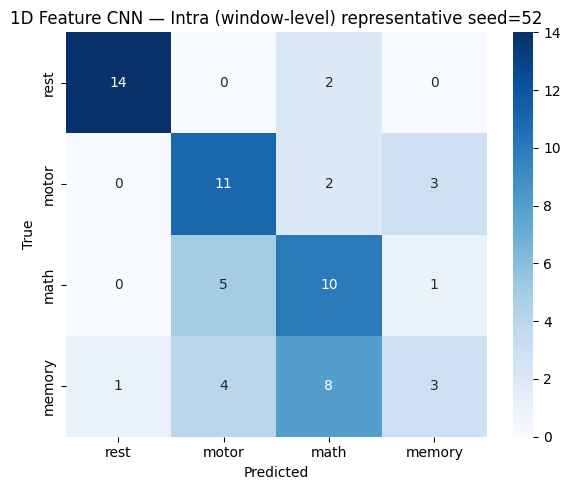

              precision    recall  f1-score   support

        rest       0.93      0.88      0.90        16
       motor       0.55      0.69      0.61        16
        math       0.45      0.62      0.53        16
      memory       0.43      0.19      0.26        16

    accuracy                           0.59        64
   macro avg       0.59      0.59      0.58        64
weighted avg       0.59      0.59      0.58        64



In [4]:

def plot_cm_and_report(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))


def run_primary_1d_feature(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    X_train_1d = prepare_1d_feature_input(X_intra_train_w)
    X_test_1d = prepare_1d_feature_input(X_intra_test_w)

    y_train_cat = keras.utils.to_categorical(y_intra_train_w, num_classes=4)
    y_test_cat = keras.utils.to_categorical(y_intra_test_w, num_classes=4)

    tr_idx, va_idx = grouped_split_indices(y_intra_train_w, train_groups, test_size=0.2, seed=seed)

    X_train_split = X_train_1d[tr_idx]
    X_val_split = X_train_1d[va_idx]
    y_train_split = y_train_cat[tr_idx]
    y_val_split = y_train_cat[va_idx]

    model = build_1d_cnn(
        input_shape=X_train_split.shape[1:],
        num_classes=4,
        dropout_rate=0.3,
        initial_filters=16,
        attention=False,
    )

    model.fit(
        X_train_split,
        y_train_split,
        validation_data=(X_val_split, y_val_split),
        batch_size=16,
        epochs=40,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
        ],
        verbose=2,
    )

    _, test_acc = model.evaluate(X_test_1d, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(X_test_1d, verbose=0), axis=1)
    return float(test_acc), y_pred


intra_results = {}

seed_runs = [42, 52, 62]
seed_accs = []
seed_preds = []
for s in seed_runs:
    acc, preds = run_primary_1d_feature(s)
    seed_accs.append(acc)
    seed_preds.append(preds)
    print(f"1D Feature CNN seed={s} intra window accuracy: {acc:.4f}")

best_i = int(np.argmax(seed_accs))
rep_seed = seed_runs[best_i]
rep_pred = seed_preds[best_i]

mean_acc = float(np.mean(seed_accs))
std_acc = float(np.std(seed_accs, ddof=1)) if len(seed_accs) > 1 else 0.0
ci95 = float(1.96 * std_acc / np.sqrt(len(seed_accs))) if len(seed_accs) > 1 else 0.0

print(f"1D Feature CNN intra window accuracy (mean over seeds): {mean_acc:.4f} ± {ci95:.4f} (95% CI)")
plot_cm_and_report(y_intra_test_w, rep_pred, f"1D Feature CNN — Intra (window-level) representative seed={rep_seed}")

intra_results["1D Feature CNN"] = mean_acc
intra_results["1D Feature CNN std"] = std_acc
intra_results["1D Feature CNN ci95"] = ci95


## Alternative model: GAT 

GAT treats sensors as graph nodes, combining temporal features with sensor connectivity. Evaluation remains at window level.

In [5]:

def build_structural_adjacency(n_sensors=248, sigma=20.0):
    idx = np.arange(n_sensors, dtype=np.float32)
    dist = np.abs(idx[:, None] - idx[None, :])
    A = np.exp(-(dist ** 2) / (2 * sigma ** 2))
    np.fill_diagonal(A, 1.0)
    degree = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    return (D_inv_sqrt @ A @ D_inv_sqrt).astype("float32")


def build_functional_adjacency(X_train):
    X_flat = X_train.transpose(1, 0, 2).reshape(X_train.shape[1], -1)
    corr = np.corrcoef(X_flat)
    corr = np.nan_to_num(corr)
    corr = np.clip(corr, 0, 1)
    np.fill_diagonal(corr, 1.0)
    degree = corr.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    return (D_inv_sqrt @ corr @ D_inv_sqrt).astype("float32")


def extract_relative_band_power(X, fs=254.0):
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 60),
    }
    n_samples, n_sensors, n_times = X.shape
    nperseg = min(256, n_times // 2)
    bp = np.zeros((n_samples, n_sensors, len(bands)), dtype="float32")

    for s in range(n_samples):
        for ch in range(n_sensors):
            freqs, psd = welch(X[s, ch], fs=fs, nperseg=nperseg)
            total = np.trapezoid(psd, freqs) + 1e-12
            for b_idx, (f_lo, f_hi) in enumerate(bands.values()):
                mask = (freqs >= f_lo) & (freqs <= f_hi)
                band = np.trapezoid(psd[mask], freqs[mask]) if mask.sum() > 1 else 0.0
                bp[s, ch, b_idx] = band / total
    return bp


class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.3):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.a_src = nn.Linear(out_features, 1, bias=False)
        self.a_dst = nn.Linear(out_features, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, H, A):
        B, N, _ = H.shape
        Wh = self.W(H)
        e_src = self.a_src(Wh)
        e_dst = self.a_dst(Wh)
        e = self.leaky_relu(e_src + e_dst.transpose(1, 2))
        mask = (A <= 0).unsqueeze(0).expand(B, -1, -1)
        e = e.masked_fill(mask, float("-inf"))
        alpha = self.dropout(torch.softmax(e, dim=-1))
        return F.elu(torch.bmm(alpha, Wh))


class MEG_GAT(nn.Module):
    def __init__(self, temporal_features=32, n_bands=5, gat_hidden=16, n_classes=4, dropout=0.3):
        super().__init__()
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=25, stride=5),
            nn.ReLU(),
            nn.Conv1d(8, temporal_features, kernel_size=10, stride=5),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.bn_temporal = nn.BatchNorm1d(temporal_features)
        self.gat1 = GATLayer(temporal_features + n_bands, gat_hidden, dropout)
        self.bn1 = nn.BatchNorm1d(gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, dropout)
        self.bn2 = nn.BatchNorm1d(gat_hidden)
        self.classifier = nn.Linear(gat_hidden, n_classes)

    def forward(self, X, A_dist, A_corr, BP):
        B, N, T = X.shape
        X = X.reshape(B * N, 1, T)
        X = self.temporal_conv(X).squeeze(-1)
        X = self.bn_temporal(X)
        X = X.reshape(B, N, -1)
        X = torch.cat([X, BP], dim=-1)
        X = self.gat1(X, A_dist)
        X = self.bn1(X.reshape(B * N, -1)).reshape(B, N, -1)
        X = self.gat2(X, A_corr)
        X = self.bn2(X.reshape(B * N, -1)).reshape(B, N, -1)
        X = X.mean(dim=1)
        return self.classifier(X)


def train_gat_window_level(X_train, y_train, X_test, y_test, train_groups_local, epochs=60, batch_size=32, lr=5e-4, patience=15):
    A_dist = torch.tensor(build_structural_adjacency(X_train.shape[1]), dtype=torch.float32, device=DEVICE)
    A_corr = torch.tensor(build_functional_adjacency(X_train), dtype=torch.float32, device=DEVICE)

    BP_train = extract_relative_band_power(X_train)
    BP_test = extract_relative_band_power(X_test)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    BP_train_t = torch.tensor(BP_train, dtype=torch.float32)

    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
    BP_test_t = torch.tensor(BP_test, dtype=torch.float32, device=DEVICE)

    train_idx, val_idx = grouped_split_indices(y_train, train_groups_local, test_size=0.2, seed=SEED)

    ds_train = TensorDataset(X_train_t[train_idx], BP_train_t[train_idx], y_train_t[train_idx])
    ds_val = TensorDataset(X_train_t[val_idx], BP_train_t[val_idx], y_train_t[val_idx])

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = MEG_GAT().to(DEVICE)
    cls_w = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    cls_w_t = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss(weight=cls_w_t)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)

    best_state = None
    best_val = -1.0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, bpb, yb in dl_train:
            xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb, A_dist, A_corr, bpb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            n_ok, n_total = 0, 0
            for xb, bpb, yb in dl_val:
                xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
                preds = model(xb, A_dist, A_corr, bpb).argmax(1)
                n_ok += (preds == yb).sum().item()
                n_total += len(yb)
            val_acc = n_ok / max(1, n_total)

        scheduler.step(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | val acc={val_acc:.4f}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val acc={best_val:.4f})")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(X_test_t, A_dist, A_corr, BP_test_t)
        y_pred = logits.argmax(1).cpu().numpy()
    test_acc = accuracy_score(y_test, y_pred)
    return model, test_acc, y_pred


Epoch   1/60 | val acc=0.2917
Epoch  10/60 | val acc=0.4479
Epoch  20/60 | val acc=0.3854
Early stopping at epoch 27 (best val acc=0.4688)
GAT intra window accuracy: 0.5469


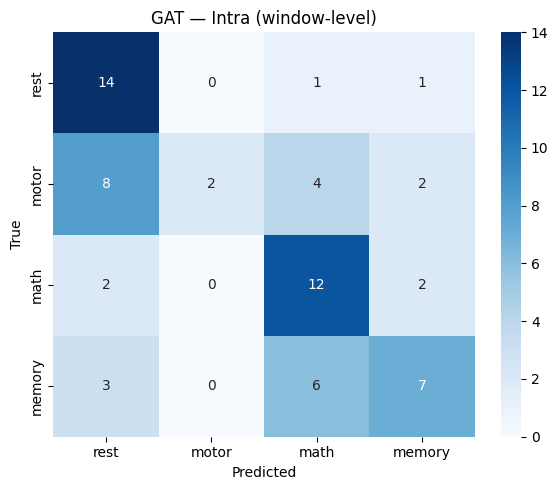

              precision    recall  f1-score   support

        rest       0.52      0.88      0.65        16
       motor       1.00      0.12      0.22        16
        math       0.52      0.75      0.62        16
      memory       0.58      0.44      0.50        16

    accuracy                           0.55        64
   macro avg       0.66      0.55      0.50        64
weighted avg       0.66      0.55      0.50        64



In [6]:

gat_model, gat_acc, gat_preds = train_gat_window_level(
    X_intra_train_w,
    y_intra_train_w,
    X_intra_test_w,
    y_intra_test_w,
    train_groups,
)
print(f"GAT intra window accuracy: {gat_acc:.4f}")
plot_cm_and_report(y_intra_test_w, gat_preds, "GAT — Intra (window-level)")
intra_results["GAT"] = float(gat_acc)


## Alternative model: CNN-GAT hybrid 

CNN-GAT reuses the temporal CNN extractor before graph attention, then predicts one label per window.

In [7]:

class TemporalAttention1D(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.attn = nn.Linear(in_features, 1)

    def forward(self, x):
        weights = torch.softmax(torch.tanh(self.attn(x)), dim=1)
        return x * weights


class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, ratio=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, max(1, channels // ratio))
        self.fc2 = nn.Linear(max(1, channels // ratio), channels)

    def forward(self, x):
        se = x.mean(dim=1)
        se = F.relu(self.fc1(se))
        se = torch.sigmoid(self.fc2(se))
        return x * se.unsqueeze(1)


class JulianCNNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dropout=0.3):
        super().__init__()
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=kernel_size // 2)
        self.bn = nn.BatchNorm1d(out_ch)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout)
        self.t_attn = TemporalAttention1D(out_ch)
        self.se = SqueezeExcite1D(out_ch)

    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.pool(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        x = self.t_attn(x)
        x = self.se(x)
        return x.transpose(1, 2)


class JulianTemporalExtractor(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.block1 = JulianCNNBlock(1, 16, 7, dropout)
        self.block2 = JulianCNNBlock(16, 32, 5, dropout)
        self.block3 = JulianCNNBlock(32, 64, 3, dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.gap(x).squeeze(-1)


class CNN_GAT(nn.Module):
    def __init__(self, n_bands=5, gat_hidden=32, n_classes=4, dropout=0.3):
        super().__init__()
        self.extractor = JulianTemporalExtractor(dropout=dropout)
        self.bn_temporal = nn.BatchNorm1d(64)
        self.gat1 = GATLayer(64 + n_bands, gat_hidden, dropout)
        self.ln1 = nn.LayerNorm(gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, dropout)
        self.ln2 = nn.LayerNorm(gat_hidden)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(gat_hidden, n_classes)

    def forward(self, X, A, BP):
        B, N, T = X.shape
        X = X.reshape(B * N, 1, T)
        X = self.extractor(X)
        X = self.bn_temporal(X)
        X = X.reshape(B, N, -1)
        X = torch.cat([X, BP], dim=-1)
        X = self.ln1(self.gat1(X, A))
        X = self.ln2(self.gat2(X, A))
        X = self.dropout(X.mean(dim=1))
        return self.classifier(X)


def train_cnn_gat_window_level(X_train, y_train, X_test, y_test, train_groups_local, epochs=60, batch_size=32, lr=1e-3, patience=15):
    A = torch.tensor(build_structural_adjacency(X_train.shape[1]), dtype=torch.float32, device=DEVICE)

    BP_train = extract_band_power(X_train)
    BP_test = extract_band_power(X_test)

    # scale stabilize bandpower features
    mu = BP_train.mean(axis=(0, 1), keepdims=True)
    sd = BP_train.std(axis=(0, 1), keepdims=True) + 1e-6
    BP_train = (BP_train - mu) / sd
    BP_test = (BP_test - mu) / sd

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    BP_train_t = torch.tensor(BP_train, dtype=torch.float32)

    X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
    BP_test_t = torch.tensor(BP_test, dtype=torch.float32, device=DEVICE)

    train_idx, val_idx = grouped_split_indices(y_train, train_groups_local, test_size=0.2, seed=SEED)

    ds_train = TensorDataset(X_train_t[train_idx], BP_train_t[train_idx], y_train_t[train_idx])
    ds_val = TensorDataset(X_train_t[val_idx], BP_train_t[val_idx], y_train_t[val_idx])

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False)

    model = CNN_GAT().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)

    best_state = None
    best_val = -1.0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, bpb, yb in dl_train:
            xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb, A, bpb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            n_ok, n_total = 0, 0
            for xb, bpb, yb in dl_val:
                xb, bpb, yb = xb.to(DEVICE), bpb.to(DEVICE), yb.to(DEVICE)
                preds = model(xb, A, bpb).argmax(1)
                n_ok += (preds == yb).sum().item()
                n_total += len(yb)
            val_acc = n_ok / max(1, n_total)

        scheduler.step(val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | val acc={val_acc:.4f}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val acc={best_val:.4f})")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t, A, BP_test_t).argmax(1).cpu().numpy()

    test_acc = accuracy_score(y_test, y_pred)
    return model, test_acc, y_pred


Epoch   1/60 | val acc=0.5000
Epoch  10/60 | val acc=0.3438
Early stopping at epoch 16 (best val acc=0.5000)
CNN-GAT intra window accuracy: 0.4219


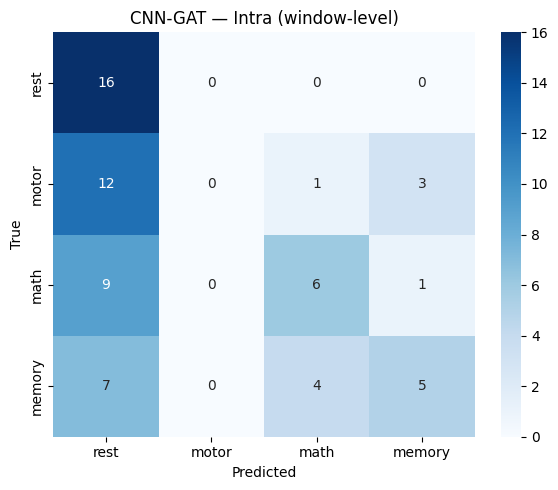

              precision    recall  f1-score   support

        rest       0.36      1.00      0.53        16
       motor       0.00      0.00      0.00        16
        math       0.55      0.38      0.44        16
      memory       0.56      0.31      0.40        16

    accuracy                           0.42        64
   macro avg       0.37      0.42      0.34        64
weighted avg       0.37      0.42      0.34        64



In [8]:

cnn_gat_model, cnn_gat_acc, cnn_gat_preds = train_cnn_gat_window_level(
    X_intra_train_w,
    y_intra_train_w,
    X_intra_test_w,
    y_intra_test_w,
    train_groups,
)

print(f"CNN-GAT intra window accuracy: {cnn_gat_acc:.4f}")
plot_cm_and_report(y_intra_test_w, cnn_gat_preds, "CNN-GAT — Intra (window-level)")
intra_results["CNN-GAT"] = float(cnn_gat_acc)


## Alternative model: EEGNet (bandpower)

This uses precomputed relative bandpower windows and reports **window-level** intra accuracy.


Epoch   1/60 | val acc=0.2427
Epoch  20/60 | val acc=0.7767
Epoch  40/60 | val acc=0.8641
Early stopping at epoch 48 (best val acc=0.8932)
EEGNet (bandpower) intra window accuracy: 0.8281


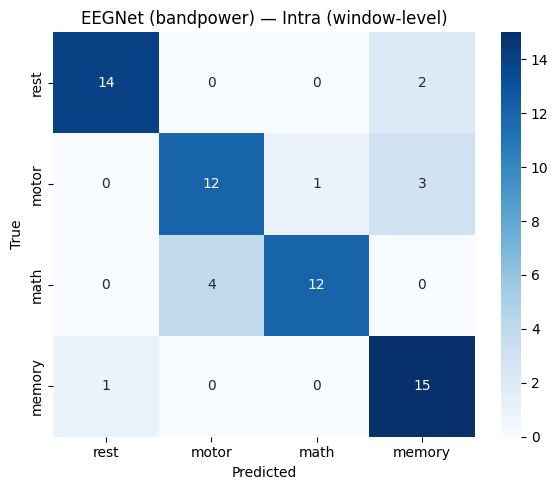

              precision    recall  f1-score   support

        rest       0.93      0.88      0.90        16
       motor       0.75      0.75      0.75        16
        math       0.92      0.75      0.83        16
      memory       0.75      0.94      0.83        16

    accuracy                           0.83        64
   macro avg       0.84      0.83      0.83        64
weighted avg       0.84      0.83      0.83        64



In [9]:
OUTPUT_DIR = "Bandpower data"

X_intra_bp_train = np.load(os.path.join(OUTPUT_DIR, "X_intra_train_bp_rel.npy"))
y_intra_bp_train = np.load(os.path.join(OUTPUT_DIR, "y_intra_train_w.npy"))
X_intra_bp_test = np.load(os.path.join(OUTPUT_DIR, "X_intra_test_bp_rel.npy"))
y_intra_bp_test = np.load(os.path.join(OUTPUT_DIR, "y_intra_test_w.npy"))


class EEGNetBandpower(nn.Module):
    def __init__(self, n_classes=4, n_channels=248, n_timesteps=5, F1=8, D=2, F2=16, kern_len=3, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, kern_len), padding=(0, kern_len // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 2)),
            nn.Dropout(dropout),
        )
        sep_kern = min(3, max(1, n_timesteps // 2))
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, sep_kern), padding=(0, sep_kern // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(dropout),
        )
        self.classifier = nn.Linear(F2, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def make_loader(X, y, batch_size=32, shuffle=True):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    preds, labels = [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        p = logits.argmax(1)
        correct += (p == yb).sum().item()
        preds.extend(p.cpu().numpy())
        labels.extend(yb.cpu().numpy())
    n = len(loader.dataset)
    return total_loss / n, correct / n, np.array(preds), np.array(labels)


def train_eegnet_bp_intra(X_train, y_train, epochs=60, batch_size=32, lr=1e-3, patience=10):
    train_idx, val_idx = train_test_split(
        np.arange(len(y_train)),
        test_size=0.2,
        stratify=y_train,
        random_state=SEED,
    )
    tr_loader = make_loader(X_train[train_idx], y_train[train_idx], batch_size=batch_size, shuffle=True)
    va_loader = make_loader(X_train[val_idx], y_train[val_idx], batch_size=batch_size, shuffle=False)

    model = EEGNetBandpower(
        n_channels=X_train.shape[1],
        n_timesteps=X_train.shape[2],
        kern_len=min(3, X_train.shape[2]),
        dropout=0.5,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        _, va_acc, _, _ = evaluate_loader(model, va_loader, criterion)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 20 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | val acc={va_acc:.4f}")

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val acc={best_acc:.4f})")
            break

    model.load_state_dict(best_state)
    return model


eegnet_bp_intra = train_eegnet_bp_intra(X_intra_bp_train, y_intra_bp_train)
criterion = nn.CrossEntropyLoss()
_, bp_intra_acc, bp_intra_preds, bp_intra_labels = evaluate_loader(
    eegnet_bp_intra,
    make_loader(X_intra_bp_test, y_intra_bp_test, batch_size=32, shuffle=False),
    criterion,
)

print(f"EEGNet (bandpower) intra window accuracy: {bp_intra_acc:.4f}")
plot_cm_and_report(bp_intra_labels, bp_intra_preds, "EEGNet (bandpower) — Intra (window-level)")
intra_results["EEGNet (bandpower)"] = float(bp_intra_acc)


## Save intra results

In [10]:
out_path = os.path.join(RESULTS_DIR, "intra_results.json")
with open(out_path, "w") as f:
    json.dump(intra_results, f, indent=2)

print("Saved:", out_path)
print(json.dumps(intra_results, indent=2))

Saved: results/intra_results.json
{
  "1D Feature CNN": 0.5625,
  "1D Feature CNN std": 0.05412658773652741,
  "1D Feature CNN ci95": 0.06125,
  "GAT": 0.546875,
  "CNN-GAT": 0.421875,
  "EEGNet (bandpower)": 0.828125
}
